<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/ML_5_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target column
df['target'] = iris.target

# Map target integers to species names
df['species'] = df['target'].map({i: name for i, name in enumerate(iris.target_names)})

# Display the first few rows
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
# Get unique values of the 'species' column
unique_species = df['species'].unique()
print(unique_species)

[np.str_('setosa') np.str_('versicolor') np.str_('virginica')]


###Pair plot

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


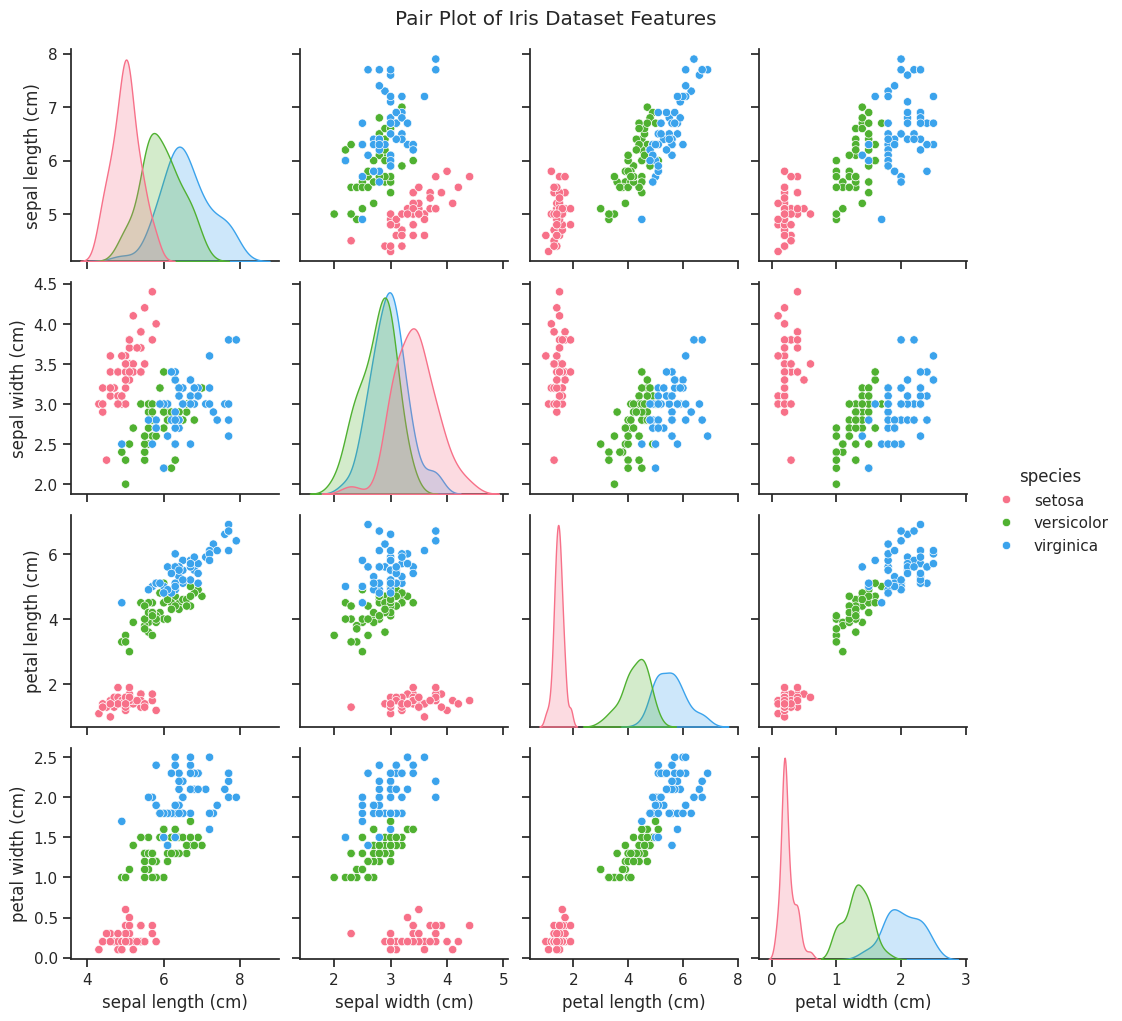

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate and display descriptive statistics
print("Descriptive Statistics:")
display(df.describe())

# 2. Create a pair plot
# Using hue='species' to color the points by species
sns.set_theme(style="ticks")
pair_plot = sns.pairplot(df.drop(columns=['target']), hue='species', palette='husl')
pair_plot.fig.suptitle('Pair Plot of Iris Dataset Features', y=1.02)

# 3. Display the plot
plt.show()


### Insights

*   **Feature Statistics**: Summary statistics, including mean, standard deviation, and quartiles, were successfully computed for sepal length, sepal width, petal length, and petal width, providing a comprehensive overview of the dataset's numerical distribution.
*   **Species Separability**: The pair plot visualization revealed that the `Iris-setosa` species is distinctly separated from `Iris-versicolor` and `Iris-virginica` across nearly all feature combinations, particularly in petal measurements.
*   **Strong Feature Correlation**: A clear positive linear relationship was observed between petal length and petal width, suggesting these two features are highly correlated and influential in species identification.
*   **Class Overlap**: While `Iris-versicolor` and `Iris-virginica` exhibit some overlap in sepal dimensions, they remain relatively distinguishable when comparing petal length against other features.


###Box plot

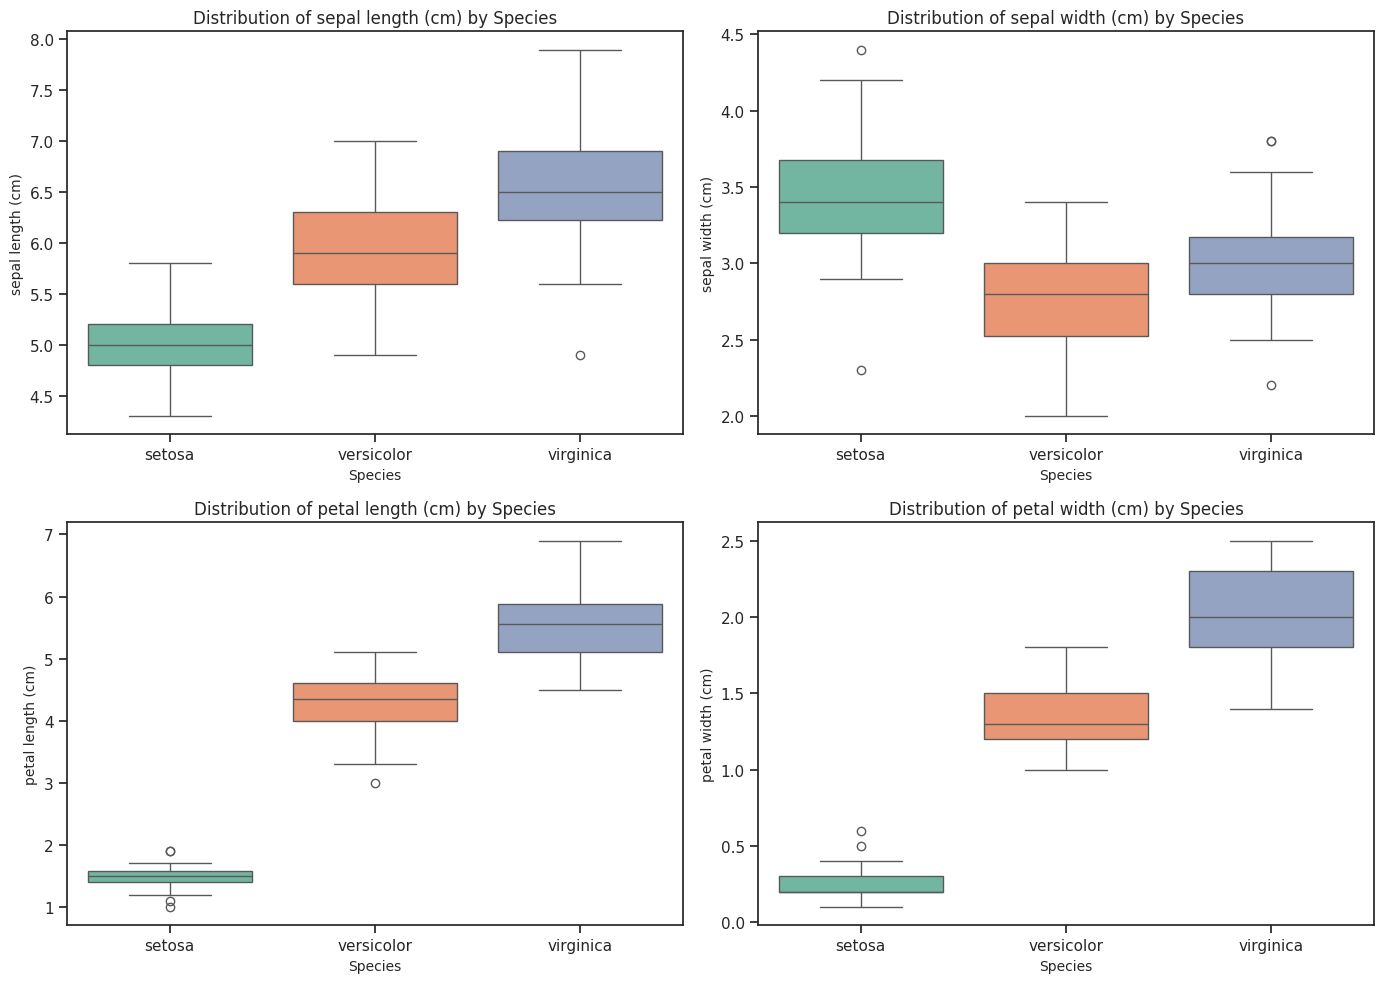

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the numerical feature names
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# 2. Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 3. Iterate through features and axes to create boxplots
for i, feature in enumerate(features):
    # Fix: Added hue='species' and legend=False to address FutureWarning
    sns.boxplot(ax=axes[i], x='species', y=feature, data=df, palette='Set2', hue='species', legend=False)
    # 4. Set descriptive titles and labels
    axes[i].set_title(f'Distribution of {feature} by Species', fontsize=12)
    axes[i].set_xlabel('Species', fontsize=10)
    axes[i].set_ylabel(feature, fontsize=10)

# 5. Apply tight layout and display the plot
plt.tight_layout()
plt.show()

##  Correlation Heatmap



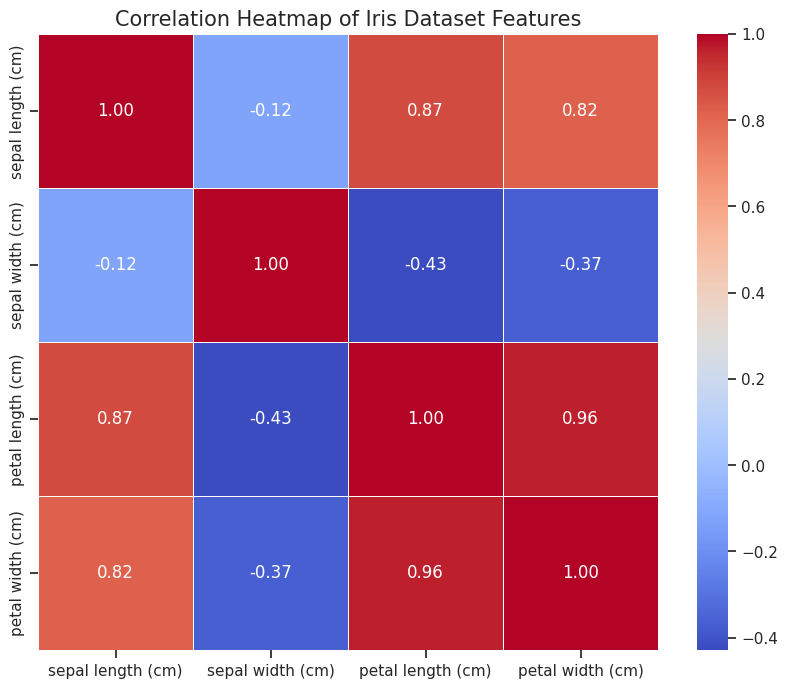

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the correlation matrix for numerical features
# Excluding 'target' and 'species' columns
corr_matrix = df.drop(columns=['target', 'species']).corr()

# 2. & 3. Create a heatmap with annotations and a specific colormap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# 4. Add a descriptive title
plt.title('Correlation Heatmap of Iris Dataset Features', fontsize=15)

# 5. Display the plot
plt.show()

### Correlation Analysis


*   **Strong Positive Correlations**: There is a very strong positive correlation between **petal length and petal width (0.96)**. Additionally, **sepal length** shows strong positive correlations with both **petal length (0.87)** and **petal width (0.82)**.
*   **Negative Correlations**: **Sepal width** exhibits a weak to moderate negative correlation with all other features, most notably with **petal length (-0.43)** and **petal width (-0.37)**.


###Apply Elbow method

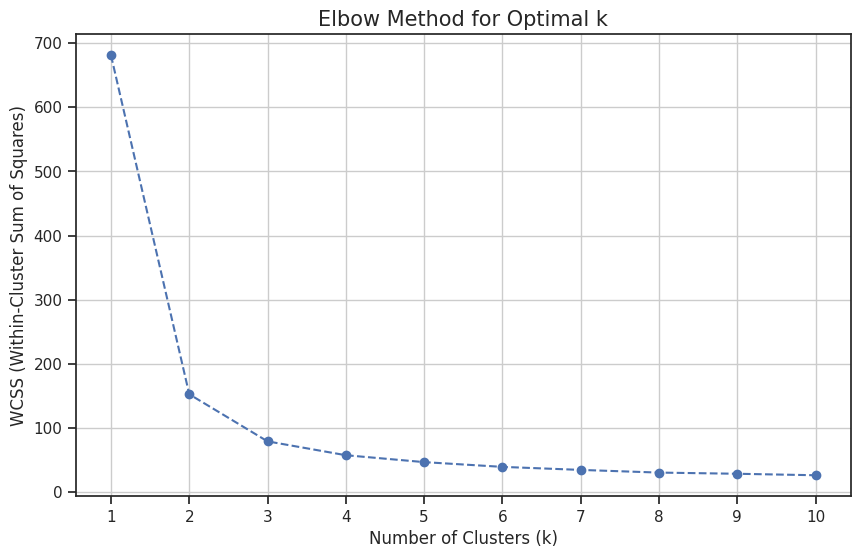

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Extract the numerical features
X = df[features]

# 2. Calculate WCSS for k from 1 to 10
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# 3. Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k', fontsize=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## K-Means Clustering




In [ ]:
from sklearn.cluster import KMeans

# 1. Initialize KMeans with k=3
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=300, random_state=42)

# 2. Fit the model to the features X
kmeans.fit(X)

# 3. & 4. Extract labels and add to the DataFrame
df['cluster'] = kmeans.labels_

# 5. Display the first few rows to verify
print("DataFrame with Cluster Labels:")
display(df.head())


DataFrame with Cluster Labels:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species,cluster
0,5.1,3.5,1.4,0.2,0,setosa,1
1,4.9,3.0,1.4,0.2,0,setosa,1
2,4.7,3.2,1.3,0.2,0,setosa,1
3,4.6,3.1,1.5,0.2,0,setosa,1
4,5.0,3.6,1.4,0.2,0,setosa,1


## Evaluation and Justification


Contingency Matrix (Species vs Cluster):


cluster,0,1,2
species,,,
setosa,0,50,0
versicolor,48,0,2
virginica,14,0,36


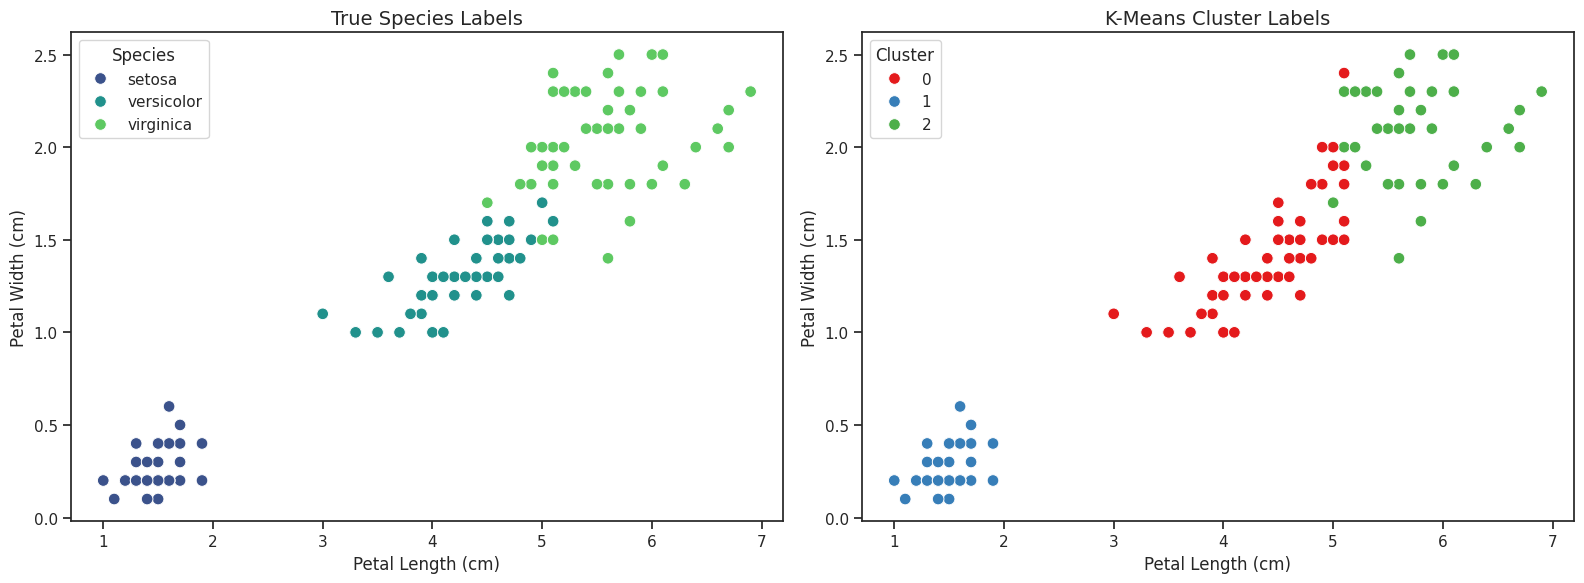

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Generate contingency matrix
contingency_matrix = pd.crosstab(df['species'], df['cluster'])
print("Contingency Matrix (Species vs Cluster):")
display(contingency_matrix)

# 2. Initialize a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3. Scatter plot for True Species
sns.scatterplot(ax=axes[0], data=df, x='petal length (cm)', y='petal width (cm)', hue='species', palette='viridis', s=70)
axes[0].set_title('True Species Labels', fontsize=14)
axes[0].set_xlabel('Petal Length (cm)', fontsize=12)
axes[0].set_ylabel('Petal Width (cm)', fontsize=12)
axes[0].legend(title='Species')

# 4. Scatter plot for K-Means Clusters
sns.scatterplot(ax=axes[1], data=df, x='petal length (cm)', y='petal width (cm)', hue='cluster', palette='Set1', s=70)
axes[1].set_title('K-Means Cluster Labels', fontsize=14)
axes[1].set_xlabel('Petal Length (cm)', fontsize=12)
axes[1].set_ylabel('Petal Width (cm)', fontsize=12)
axes[1].legend(title='Cluster')

# 5. Adjust layout and display
plt.tight_layout()
plt.show()

### Clustering Interpretation and Justification

Based on the contingency matrix and the comparative scatter plots, we can draw the following conclusions regarding the K-Means (k=3) clustering performance:

*   **Perfect Separation of Iris-setosa**: The algorithm perfectly isolated `Iris-setosa` into its own cluster (Cluster 1). This aligns with our earlier exploratory data analysis, which showed that setosa is distinctly separated from other species, particularly in petal dimensions.
*   **Partial Overlap in Versicolor and Virginica**: While the algorithm successfully identified three distinct groupings, there is noticeable overlap between `Iris-versicolor` and `Iris-virginica`.
    *   **Cluster 0** is predominantly `versicolor` (48/50) but includes 14 `virginica` samples.
    *   **Cluster 2** captures the majority of `virginica` (36/50) but also includes 2 `versicolor` samples.


## Logostic Regression




In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 1. Define feature matrix X and target vector y
X = df[features]
y = df['target']

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Logistic Regression model
# Increasing max_iter to ensure convergence
log_reg = LogisticRegression(max_iter=200)

# 4. Fit the model to the training data
log_reg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Logistic Regression model trained successfully.
Training set size: 120
Testing set size: 30


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Make predictions on the test set
y_pred = log_reg.predict(X_test)

# 2. Calculate and print evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 3. Create a temporary DataFrame for visualization
test_results = X_test.copy()
test_results['true_species'] = y_test.map({i: name for i, name in enumerate(iris.target_names)})
test_results['predicted_species'] = pd.Series(y_pred, index=X_test.index).map({i: name for i, name in enumerate(iris.target_names)})

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



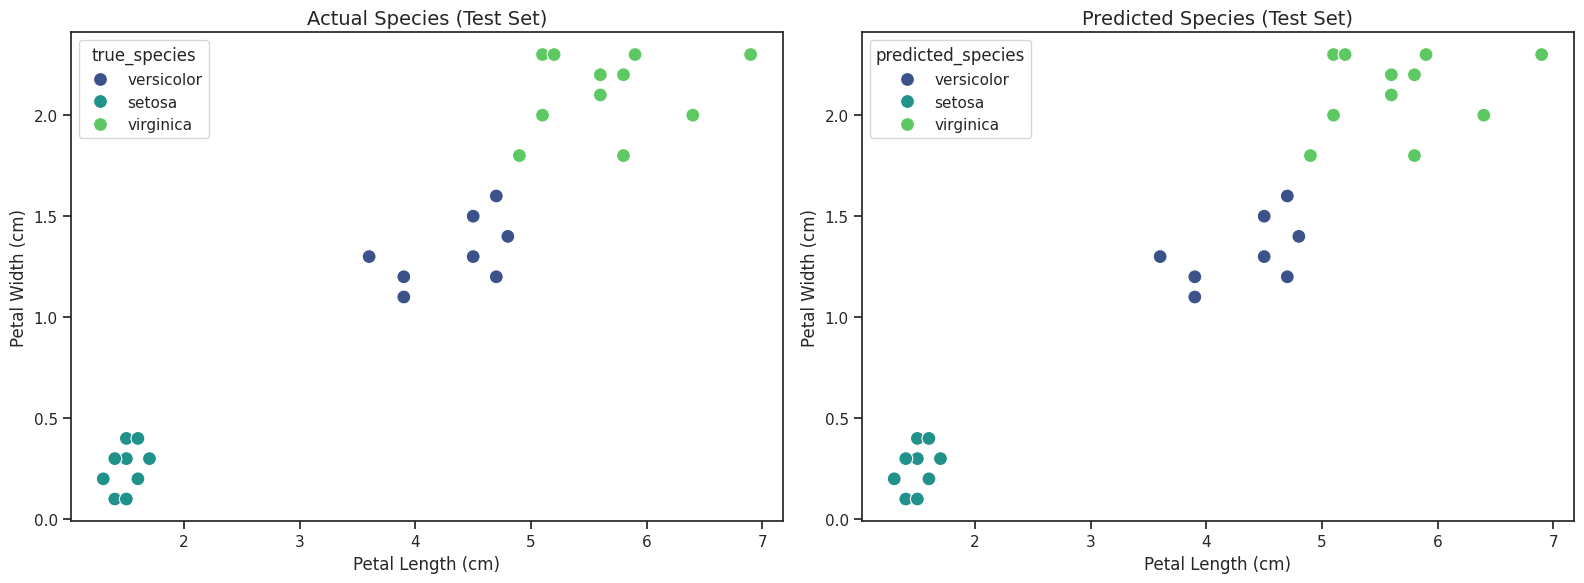

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a side-by-side comparison of True vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: True Labels (Before/Actual)
sns.scatterplot(ax=axes[0], data=test_results, x='petal length (cm)', y='petal width (cm)', hue='true_species', palette='viridis', s=100)
axes[0].set_title('Actual Species (Test Set)', fontsize=14)
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')

# Plot 2: Predicted Labels (After/Model)
sns.scatterplot(ax=axes[1], data=test_results, x='petal length (cm)', y='petal width (cm)', hue='predicted_species', palette='viridis', s=100)
axes[1].set_title('Predicted Species (Test Set)', fontsize=14)
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')

plt.tight_layout()
plt.show()

Naïve Bayes Model Accuracy: 100.00%


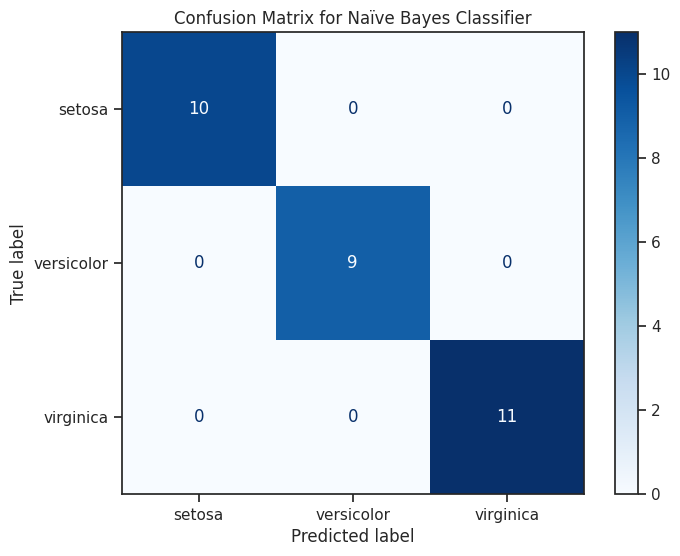

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize the Naïve Bayes model
nb_model = GaussianNB()

# 2. Fit the model to the training data
nb_model.fit(X_train, y_train)

# 3. Predict on the test set
y_pred_nb = nb_model.predict(X_test)

# 4. Evaluate the model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

print(f"Naïve Bayes Model Accuracy: {accuracy_nb:.2%}")

# 5. Visualize the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_nb, display_labels=iris.target_names)
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Confusion Matrix for Naïve Bayes Classifier')
plt.show()

## kNN Accuracy Study


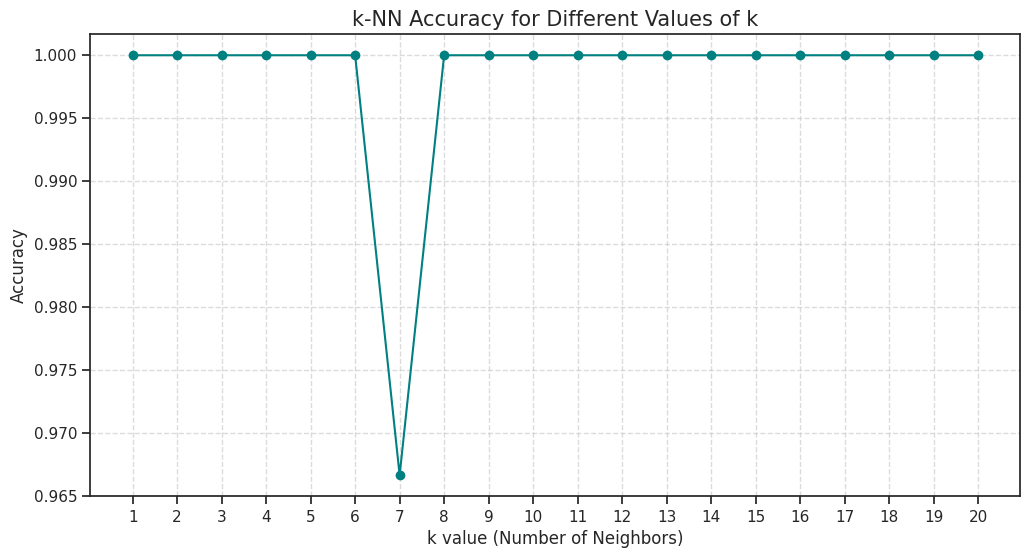

k=1: Accuracy=1.0000
k=2: Accuracy=1.0000
k=3: Accuracy=1.0000
k=4: Accuracy=1.0000
k=5: Accuracy=1.0000
k=6: Accuracy=1.0000
k=7: Accuracy=0.9667
k=8: Accuracy=1.0000
k=9: Accuracy=1.0000
k=10: Accuracy=1.0000
k=11: Accuracy=1.0000
k=12: Accuracy=1.0000
k=13: Accuracy=1.0000
k=14: Accuracy=1.0000
k=15: Accuracy=1.0000
k=16: Accuracy=1.0000
k=17: Accuracy=1.0000
k=18: Accuracy=1.0000
k=19: Accuracy=1.0000
k=20: Accuracy=1.0000


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 2. Create an empty list to store accuracy values
knn_accuracies = []
k_range = range(1, 21)

# 3. & 4. Implement a loop to iterate through k values
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)

    # 5. Calculate accuracy and append to list
    acc = accuracy_score(y_test, y_pred_knn)
    knn_accuracies.append(acc)

# 6. Generate a line plot to visualize the relationship
plt.figure(figsize=(12, 6))
plt.plot(k_range, knn_accuracies, marker='o', linestyle='-', color='teal')
plt.title('k-NN Accuracy for Different Values of k', fontsize=15)
plt.xlabel('k value (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Print the results for reference
for k, acc in zip(k_range, knn_accuracies):
    print(f'k={k}: Accuracy={acc:.4f}')



#### Significance in the Iris Dataset
For the Iris dataset, distance metrics are highly effective because the features (sepal and petal dimensions) are all measured in the same unit (cm) and represent physical attributes.

1.  **Species Separation**: As seen in the earlier exploratory analysis, `Iris-setosa` is geographically isolated in the feature space. Its Euclidean distance to any point in the `versicolor` or `virginica` clusters is significantly larger than the distance between points within the clusters. This makes kNN highly accurate for setosa.
2.  **Handling Overlap**: `Iris-versicolor` and `Iris-virginica` have overlapping feature distributions, particularly in sepal dimensions. Here, the distance metric's precision is vital. The algorithm relies on the fact that, despite the overlap, a point's immediate neighbors are still statistically more likely to belong to the same species.
3.  **Feature Influence**: Since petal length and width show high correlation and distinct ranges for each species, they contribute the most to the distance calculation, effectively driving the classification boundary where species overlap is minimal.

## Decision Tree




In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize the Decision Tree classifier
# Setting random_state=42 for reproducibility
dt_classifier = DecisionTreeClassifier(random_state=42)

# 2. Fit the model to the training data
dt_classifier.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

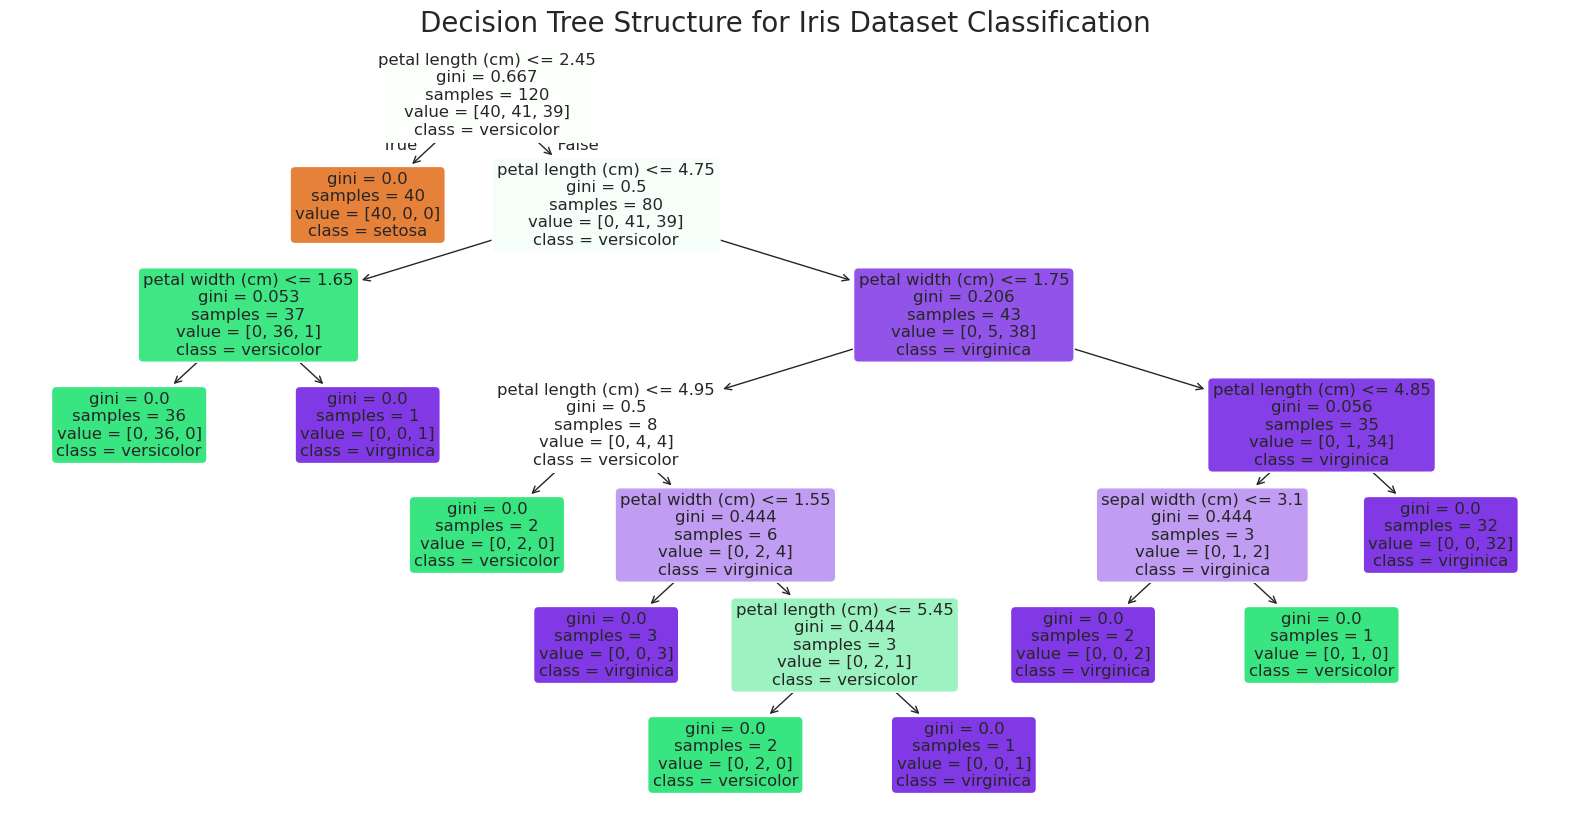

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 1. Create a large figure for readability
plt.figure(figsize=(20, 10))

# 2. Plot the decision tree with enhancements
plot_tree(dt_classifier,
          feature_names=features,
          class_names=list(iris.target_names),
          filled=True,
          rounded=True)

# 3. Add a descriptive title and display the plot
plt.title('Decision Tree Structure for Iris Dataset Classification', fontsize=20)
plt.show()

## Train Random Forest



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest classifier with 100 estimators
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Fit the model to the training data
rf_classifier.fit(X_train, y_train)

print("Random Forest classifier trained successfully.")

Random Forest classifier trained successfully.


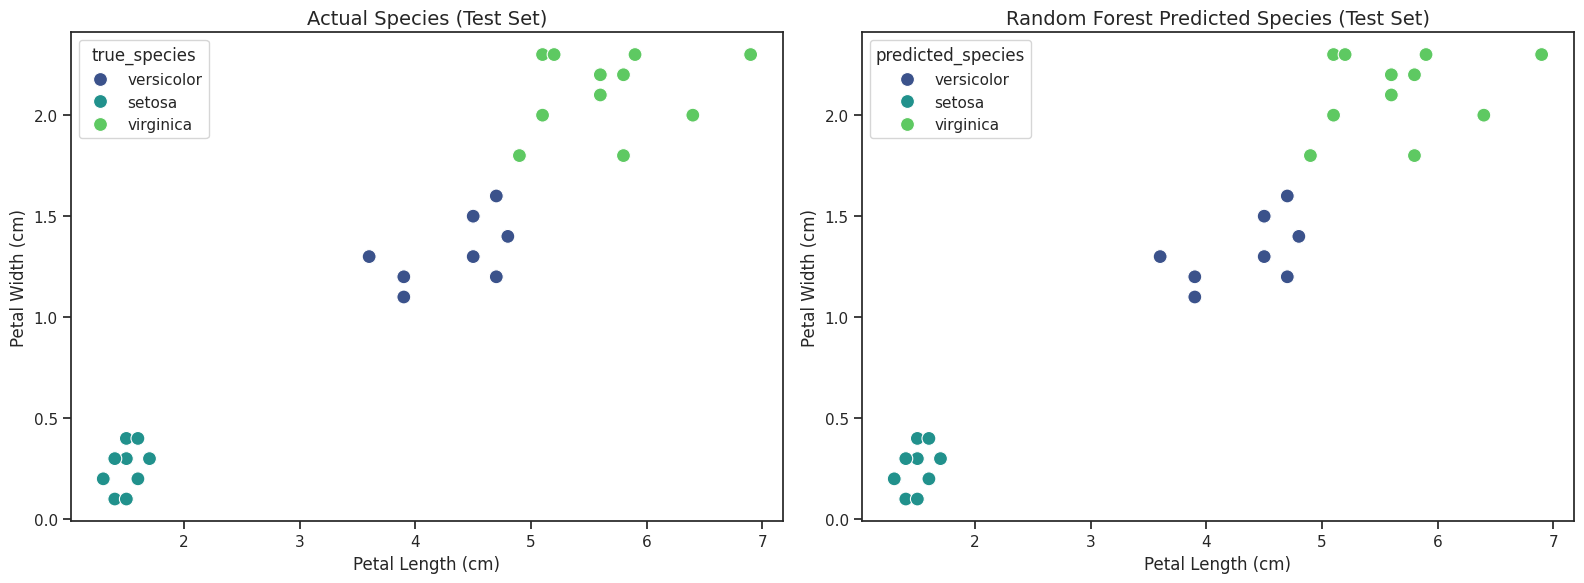

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create a temporary DataFrame for Random Forest visualization
rf_results = X_test.copy()
rf_results['true_species'] = y_test.map({i: name for i, name in enumerate(iris.target_names)})
rf_results['predicted_species'] = pd.Series(y_pred_rf, index=X_test.index).map({i: name for i, name in enumerate(iris.target_names)})

# 2. Create a side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: True Labels
sns.scatterplot(ax=axes[0], data=rf_results, x='petal length (cm)', y='petal width (cm)', hue='true_species', palette='viridis', s=100)
axes[0].set_title('Actual Species (Test Set)', fontsize=14)
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')

# Plot 2: Predicted Labels (Random Forest)
sns.scatterplot(ax=axes[1], data=rf_results, x='petal length (cm)', y='petal width (cm)', hue='predicted_species', palette='viridis', s=100)
axes[1].set_title('Random Forest Predicted Species (Test Set)', fontsize=14)
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# 1. Predictions for Decision Tree
y_pred_dt = dt_classifier.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# 2. Predictions for Random Forest
y_pred_rf = rf_classifier.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# 3. Display the comparison results
print(f"Decision Tree Accuracy: {dt_accuracy:.2%}")
print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

# 4. Create a simple comparison DataFrame for visualization
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [dt_accuracy, rf_accuracy]
})

display(comparison_df)

Decision Tree Accuracy: 100.00%
Random Forest Accuracy: 100.00%


,Model,Accuracy
0,Decision Tree,1.0
1,Random Forest,1.0


## Train SVM Models



In [ ]:
from sklearn.svm import SVC

# 1. Initialize the SVM classifiers
svm_linear = SVC(kernel='linear')
svm_rbf = SVC(kernel='rbf')

# 2. Fit the models to the training data
svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

print("SVM models (Linear and RBF) trained successfully.")

SVM models (Linear and RBF) trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score

# 1. Generate predictions for the test set using svm_linear
y_pred_linear = svm_linear.predict(X_test)

# 2. Generate predictions for the test set using svm_rbf
y_pred_rbf = svm_rbf.predict(X_test)

# 3. Calculate accuracy for both models
accuracy_linear = accuracy_score(y_test, y_pred_linear)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

# 4. Print the accuracy scores
print(f"Linear SVM Accuracy: {accuracy_linear:.2%}")
print(f"RBF SVM Accuracy: {accuracy_rbf:.2%}")

Linear SVM Accuracy: 100.00%
RBF SVM Accuracy: 100.00%


In [ ]:
import pandas as pd

# 1. Collect accuracy scores into a dictionary
# Note: For k-NN, we'll use k=3 as a representative example
comparison_data = {
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'k-Nearest Neighbors (k=3)',
        'Decision Tree',
        'Random Forest',
        'SVM (Linear Kernel)',
        'SVM (RBF Kernel)'
    ],
    'Accuracy Score': [
        accuracy,
        accuracy_nb,
        knn_accuracies[2],  # k=3
        dt_accuracy,
        rf_accuracy,
        accuracy_linear,
        accuracy_rbf
    ]
}

# 2. Create the comparison DataFrame
all_models_df = pd.DataFrame(comparison_data)

# 3. Format the accuracy as a percentage for better readability
all_models_df['Accuracy %'] = all_models_df['Accuracy Score'].map(lambda x: f"{x:.2%}")

# 4. Display the final comparison table
print("Final Model Performance Comparison:")
display(all_models_df[['Model', 'Accuracy %']])

Final Model Performance Comparison:


,Model,Accuracy %
0,Logistic Regression,100.00%
1,Nave Bayes,100.00%
2,k-Nearest Neighbors (k=3),100.00%
3,Decision Tree,100.00%
4,Random Forest,100.00%
5,SVM (Linear Kernel),100.00%
6,SVM (RBF Kernel),100.00%
